# Explainable AI: Federated Autoencoder

This notebook uses SHAP and LIME to explain actual reconstruction-loss predictions from the trained Federated Learning global autoencoder. Larger contributions increase reconstruction loss and support an anomalous decision.

Examples are selected from the real UNSW-NB15 test set. The notebook does not retrain the model, refit preprocessing, implement threat scoring, or implement the dashboard.

In [1]:
# Install compatible explainability dependencies in the active kernel.
%pip install "numpy<2.2" lime shap -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import pickle
from pathlib import Path

import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import tensorflow as tf
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams['figure.figsize'] = (10, 6)

project_root = Path.cwd().resolve()
for candidate in (project_root, project_root.parent):
    if (candidate / 'dataset' / 'UNSW-NB15').exists():
        project_root = candidate
        break

data_dir = project_root / 'dataset' / 'UNSW-NB15'
model_dir = project_root / 'models' / 'trained_models'
explanations_dir = project_root / 'results' / 'explanations'
plots_dir = project_root / 'results' / 'plots'
explanations_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'federated_autoencoder_model.h5'
pipeline_path = project_root / 'models' / 'preprocessing_pipeline.pkl'
metadata_path = model_dir / 'federated_autoencoder_metadata.pkl'
for required_path in (model_path, pipeline_path, metadata_path):
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required artifact: {required_path}')

train_df = pd.read_csv(data_dir / 'UNSW_NB15_training-set.csv')
test_df = pd.read_csv(data_dir / 'UNSW_NB15_testing-set.csv')
with pipeline_path.open('rb') as file:
    preprocessor = pickle.load(file)
with metadata_path.open('rb') as file:
    model_metadata = pickle.load(file)
global_model = keras.models.load_model(model_path, compile=False)

feature_cols = [column for column in train_df.columns if column not in ('label', 'attack_cat')]
X_train = np.asarray(preprocessor.transform(train_df[feature_cols]), dtype=np.float32)
X_test = np.asarray(preprocessor.transform(test_df[feature_cols]), dtype=np.float32)
y_test = test_df['label'].astype(int).to_numpy()
threshold = float(model_metadata['anomaly_threshold'])
feature_names = np.asarray(preprocessor.get_feature_names_out(), dtype=str)
assert X_train.shape[1] == X_test.shape[1] == len(feature_names) == global_model.input_shape[-1]
print(f'Loaded global model; test shape={X_test.shape}; threshold={threshold:.6f}')

Loaded global model; test shape=(82332, 195); threshold=0.031196


In [3]:
def reconstruction_loss(features):
    features = np.asarray(features, dtype=np.float32)
    reconstructed = global_model.predict(features, batch_size=1024, verbose=0)
    return np.mean(np.square(features - reconstructed), axis=1)

test_errors = reconstruction_loss(X_test)
test_predictions = (test_errors > threshold).astype(int)

# Choose real examples: normal, known attack, and Worms (the zero-day category used in Step 4) when present.
test_categories = test_df['attack_cat'].fillna('Unknown').astype(str)
normal_index = int(np.flatnonzero(y_test == 0)[0])
known_attack_index = int(np.flatnonzero(y_test == 1)[0])
unseen_mask = (y_test == 1) & (test_categories == 'Worms').to_numpy()
example_indices = {'normal': normal_index, 'known_attack': known_attack_index}
if unseen_mask.any():
    example_indices['unseen_zero_day'] = int(np.flatnonzero(unseen_mask)[0])

example_records = []
for example_type, index in example_indices.items():
    example_records.append({
        'example': example_type,
        'test_index': index,
        'attack_cat': str(test_df.iloc[index]['attack_cat']),
        'true_label': int(y_test[index]),
        'reconstruction_loss': float(test_errors[index]),
        'predicted_anomaly': int(test_predictions[index]),
    })
example_summary = pd.DataFrame(example_records)
example_summary.to_csv(explanations_dir / '06_example_predictions.csv', index=False)
print(example_summary.to_string(index=False))
if 'unseen_zero_day' not in example_indices:
    print('No Worms rows were available in this test set; only normal and known-attack examples are explained.')

        example  test_index     attack_cat  true_label  reconstruction_loss  predicted_anomaly
         normal           0         Normal           0             0.017183                  0
   known_attack         243 Reconnaissance           1             0.031949                  1
unseen_zero_day         387          Worms           1             0.022463                  0


  0%|          | 0/3 [00:00<?, ?it/s]

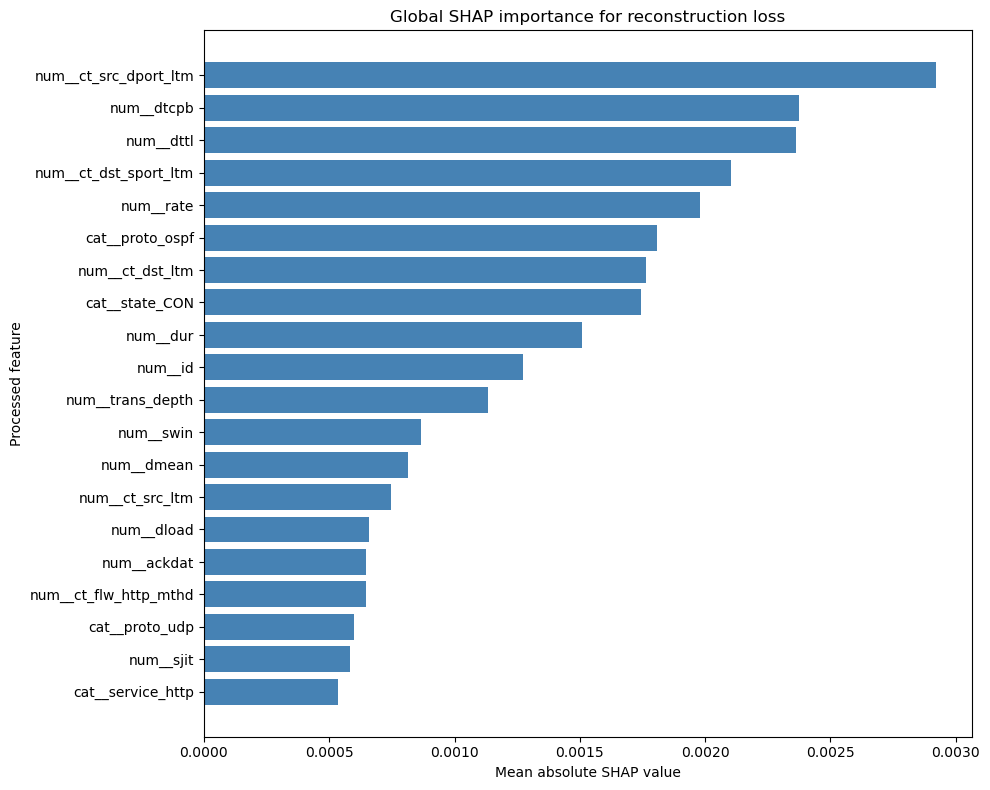

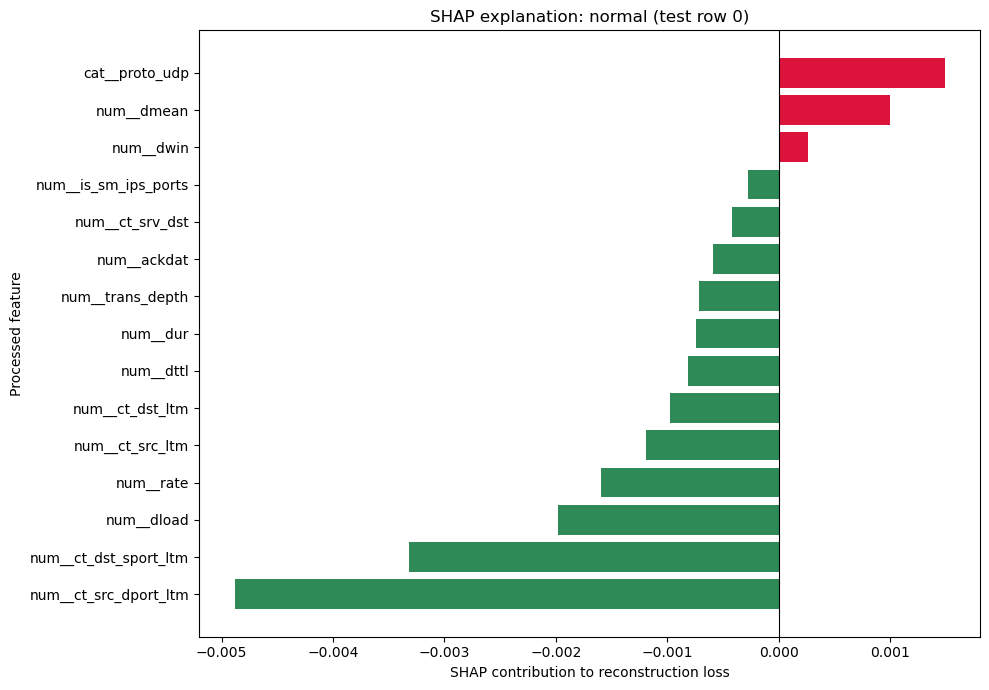

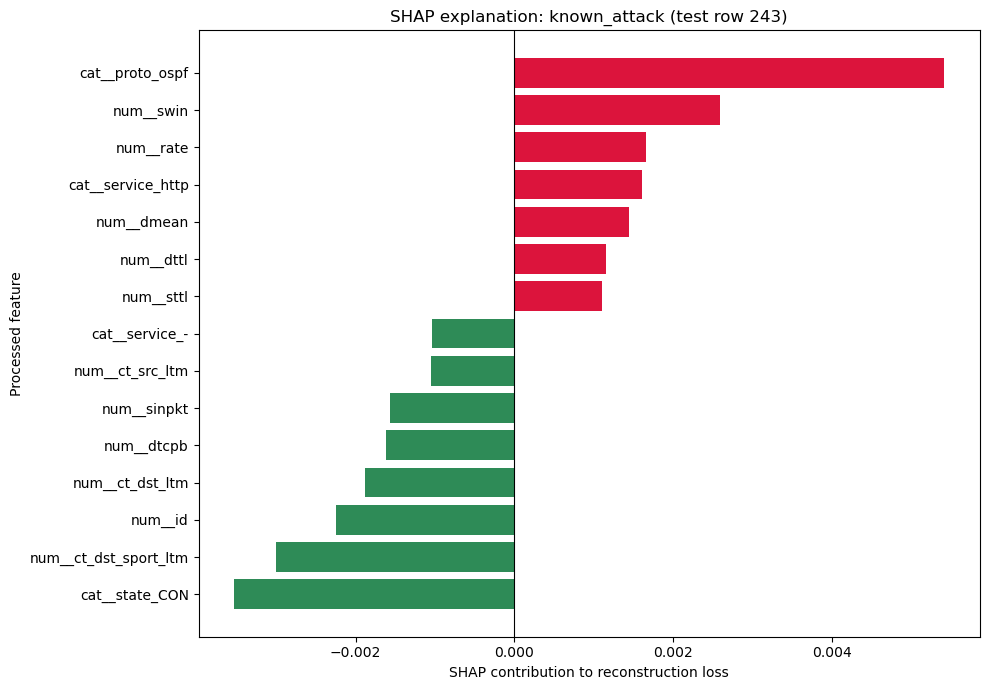

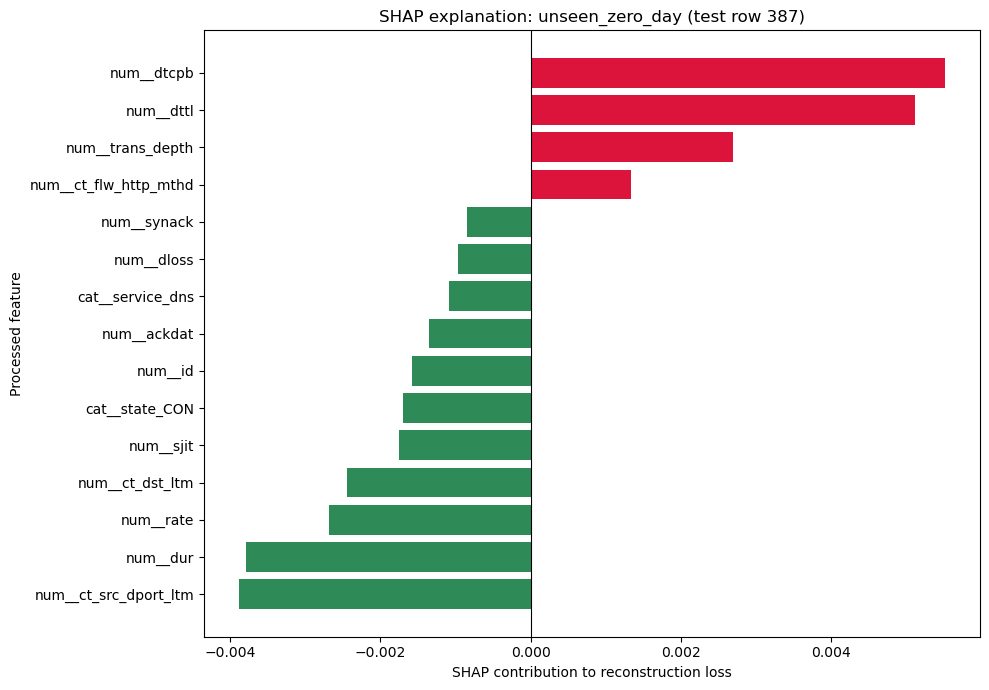

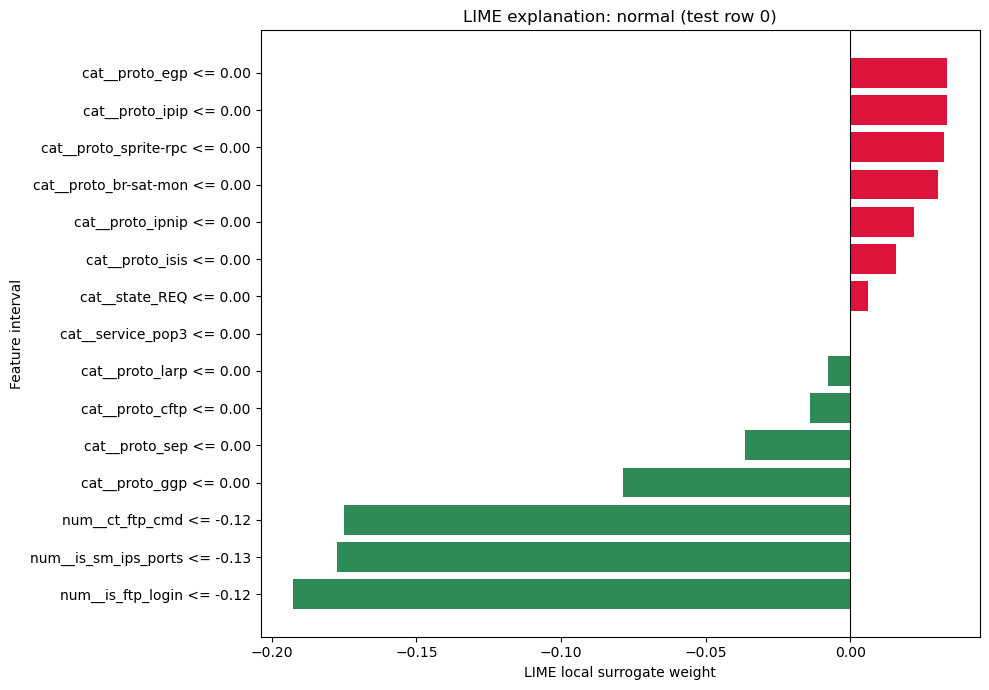

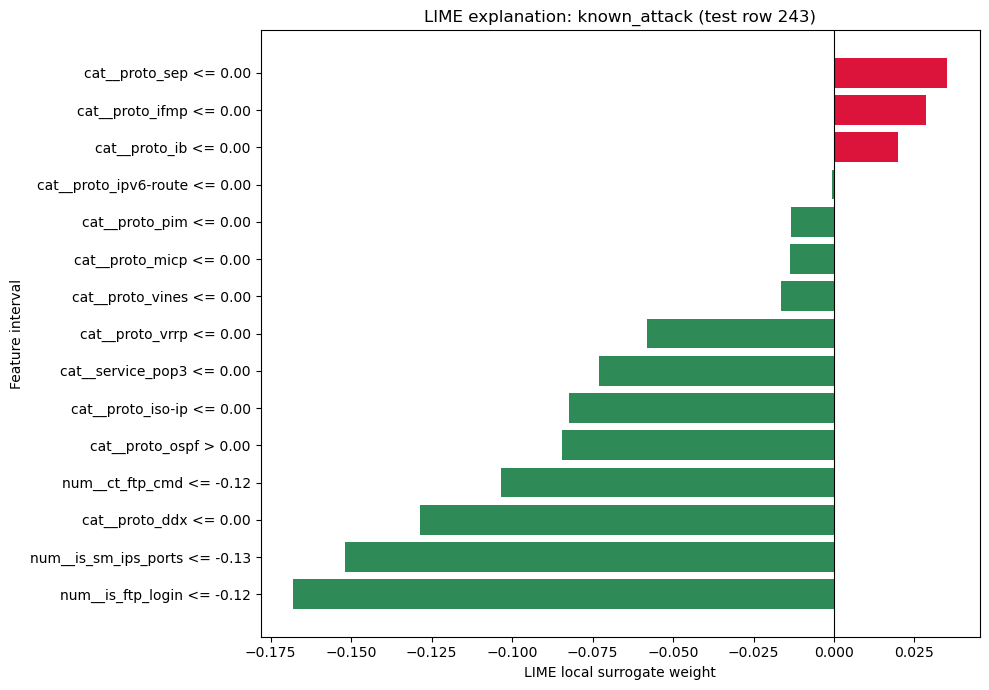

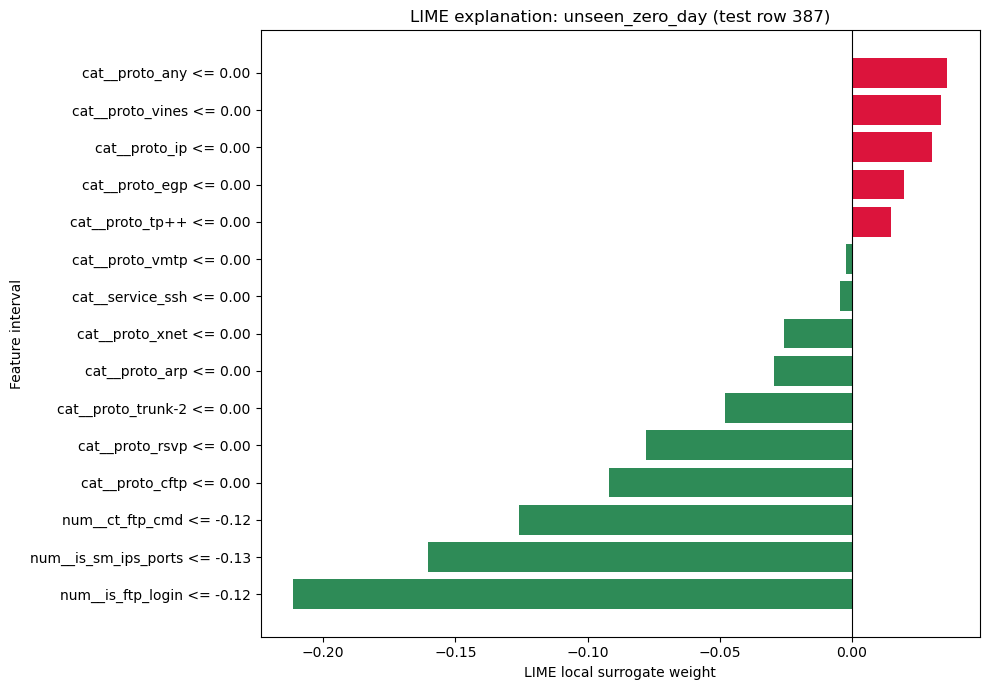

Explanations saved under C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\explanations
Plots saved under C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\plots


In [4]:
# Kernel SHAP explains the scalar reconstruction loss in processed feature space.
background_indices = np.linspace(0, len(X_train) - 1, min(40, len(X_train)), dtype=int)
background = X_train[background_indices]
shap_explainer = shap.KernelExplainer(reconstruction_loss, background)
explanation_indices = list(example_indices.values())
shap_raw = shap_explainer.shap_values(
    X_test[explanation_indices], nsamples=100, l1_reg='num_features(20)'
)
shap_values = np.asarray(shap_raw[0] if isinstance(shap_raw, list) else shap_raw)
if shap_values.ndim == 3:
    shap_values = shap_values[0]
assert shap_values.shape == (len(explanation_indices), X_test.shape[1])

global_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.mean(np.abs(shap_values), axis=0),
}).sort_values('mean_abs_shap', ascending=False)
global_importance.to_csv(explanations_dir / '06_shap_global_feature_importance.csv', index=False)

top_global = global_importance.head(20).sort_values('mean_abs_shap')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_global['feature'], top_global['mean_abs_shap'], color='steelblue')
ax.set(xlabel='Mean absolute SHAP value', ylabel='Processed feature',
       title='Global SHAP importance for reconstruction loss')
fig.tight_layout()
fig.savefig(plots_dir / '06_shap_global_feature_importance.png', dpi=200)
plt.show()

for position, (example_type, index) in enumerate(example_indices.items()):
    local_values = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_values[position],
        'absolute_shap': np.abs(shap_values[position]),
        'processed_value': X_test[index],
    }).sort_values('absolute_shap', ascending=False).head(15).sort_values('shap_value')
    local_values.to_csv(explanations_dir / f'06_shap_{example_type}.csv', index=False)
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['crimson' if value > 0 else 'seagreen' for value in local_values['shap_value']]
    ax.barh(local_values['feature'], local_values['shap_value'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set(xlabel='SHAP contribution to reconstruction loss', ylabel='Processed feature',
           title=f'SHAP explanation: {example_type} (test row {index})')
    fig.tight_layout()
    fig.savefig(plots_dir / f'06_shap_{example_type}.png', dpi=200)
    plt.show()

# LIME fits a local surrogate around each same real test example.
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, feature_names=feature_names.tolist(), mode='regression',
    discretize_continuous=True, random_state=SEED, verbose=False,
)
for example_type, index in example_indices.items():
    lime_explanation = lime_explainer.explain_instance(
        X_test[index], reconstruction_loss, num_features=15, num_samples=300
    )
    lime_values = pd.DataFrame(
        lime_explanation.as_list(), columns=['feature', 'lime_weight']
    )
    lime_values.to_csv(explanations_dir / f'06_lime_{example_type}.csv', index=False)
    lime_explanation.save_to_file(
        str(explanations_dir / f'06_lime_{example_type}.html')
    )
    plot_values = lime_values.sort_values('lime_weight')
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['crimson' if value > 0 else 'seagreen' for value in plot_values['lime_weight']]
    ax.barh(plot_values['feature'], plot_values['lime_weight'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set(xlabel='LIME local surrogate weight', ylabel='Feature interval',
           title=f'LIME explanation: {example_type} (test row {index})')
    fig.tight_layout()
    fig.savefig(plots_dir / f'06_lime_{example_type}.png', dpi=200)
    plt.show()

metadata = {
    'model': str(model_path),
    'threshold': threshold,
    'examples': example_records,
    'shap_background_rows': len(background),
    'shap_samples_per_explanation': 100,
    'lime_samples_per_explanation': 300,
}
with (explanations_dir / '06_explainability_metadata.json').open('w', encoding='utf-8') as file:
    json.dump(metadata, file, indent=2)
print(f'Explanations saved under {explanations_dir}')
print(f'Plots saved under {plots_dir}')